In [45]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [46]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sanka\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [47]:
df = pd.read_csv(r"C:\Users\sanka\Desktop\FUTURE_ML_02\customer_support_tickets.csv")

In [48]:
df = df[['Ticket Description', 'Ticket Type']]
df.columns = ['ticket_text', 'category']

In [49]:
stop_words = set(stopwords.words('english'))

In [50]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

In [51]:
df['clean_text'] = df['ticket_text'].apply(clean_text)


In [52]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])
y = df['category']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [54]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [55]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.19834710743801653

Classification Report:
                       precision    recall  f1-score   support

     Billing inquiry       0.19      0.14      0.16       357
Cancellation request       0.18      0.20      0.19       327
     Product inquiry       0.19      0.18      0.18       316
      Refund request       0.21      0.24      0.22       345
     Technical issue       0.22      0.24      0.23       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694


Confusion Matrix:
 [[49 80 66 87 75]
 [52 65 62 75 73]
 [54 66 56 65 75]
 [61 71 60 82 71]
 [47 83 54 81 84]]


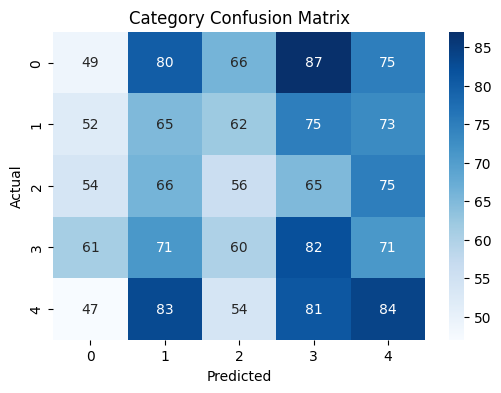

In [56]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Category Confusion Matrix")
plt.show()


In [57]:
def assign_priority(text):
    text = text.lower()
    if any(word in text for word in ['urgent', 'failed', 'error', 'down']):
        return 'High'
    elif any(word in text for word in ['delay', 'slow', 'issue']):
        return 'Medium'
    else:
        return 'Low'

In [58]:
df['Priority'] = df['ticket_text'].apply(assign_priority)

In [59]:
print("\nSample Output:")
print(df[['ticket_text', 'category', 'Priority']].head())


Sample Output:
                                         ticket_text         category Priority
0  I'm having an issue with the {product_purchase...  Technical issue   Medium
1  I'm having an issue with the {product_purchase...  Technical issue   Medium
2  I'm facing a problem with my {product_purchase...  Technical issue      Low
3  I'm having an issue with the {product_purchase...  Billing inquiry   Medium
4  I'm having an issue with the {product_purchase...  Billing inquiry   Medium


## Interactive Priority Assignment UI

In [60]:
import gradio as gr

def predict_ticket(ticket_text):
   
    priority = assign_priority(ticket_text)

    cleaned = clean_text(ticket_text)
    text_vectorized = vectorizer.transform([cleaned])
    category = model.predict(text_vectorized)[0]
    
    proba = model.predict_proba(text_vectorized)[0]
    confidence = max(proba) * 100
    
    return {
        "Category": category,
        "Priority": priority,
        "Confidence": f"{confidence:.2f}%"
    }

In [61]:
#gardio interface used it and enjoy simple and easy to understand
demo = gr.Interface(
    fn=predict_ticket,
    inputs=gr.Textbox(
        label="Enter Support Ticket Description",
        placeholder="Describe your issue here...",
        lines=5
    ),
    outputs=gr.JSON(label="Ticket Analysis"),
    title="Customer Support Ticket Analyzer",
    description="Enter a support ticket description.",
    examples=[
        ["My login is not working and I can't access my account"],
        ["I need to cancel my subscription immediately"],
        ["Can you tell me more about the premium features?"],
        ["The payment failed multiple times, this is urgent!"],
        ["I want a refund for my last purchase"]
    ],
    theme="hard"
)

demo.launch(share=False, inbrowser=True)

c:\Users\sanka\AppData\Local\Programs\Python\Python313\Lib\site-packages\gradio\blocks.py:982: UserWarning: Cannot load hard. Caught Exception: module 'huggingface_hub.utils' has no attribute '_errors'
  warnings.warn(f"Cannot load {theme}. Caught Exception: {str(e)}")


Running on local URL:  http://127.0.0.1:7862

To create a public link, set `share=True` in `launch()`.
